# Stage 11 — Evaluation & Risk Communication (ASML)
Bootstrap vs parametric CIs, scenario comparison (baseline vs polynomial term), subgroup diagnostics, and stakeholder summary.


In [1]:
from __future__ import annotations
import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from dotenv import load_dotenv

# Resolve project root when running from project/notebooks
project_root = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.append(str(project_root / "src"))

load_dotenv(project_root / ".env")

from storage import env_paths, read_df, write_df
from evaluation import rmse, mae, bootstrap_ci, parametric_ci_rmse, subgroup_metric

RAW_DIR, PROC_DIR = env_paths(project_root)
OUT_DIR = project_root / "outputs" / "eval"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def stamp(): return datetime.now().strftime("%Y%m%d-%H%M")


Load engineered features

In [2]:
feat_candidates  = sorted(PROC_DIR.glob("asml_features_*.parquet")) + sorted(PROC_DIR.glob("asml_features_*.csv"))
clean_candidates = sorted(PROC_DIR.glob("asml_cleaned_*.parquet")) + sorted(PROC_DIR.glob("asml_cleaned_*.csv"))
raw_candidates   = sorted(RAW_DIR.glob("api_*ASML_*.csv"))

if feat_candidates:
    path = feat_candidates[-1]
    print("Using FEATURES:", path.name)
    df = read_df(path, parse_dates=["date"])
elif clean_candidates:
    path = clean_candidates[-1]
    print("Using CLEANED:", path.name)
    df = read_df(path, parse_dates=["date"])
else:
    path = raw_candidates[-1]
    print("Using RAW:", path.name)
    df = read_df(path, parse_dates=["date"])

df = df.sort_values("date").reset_index(drop=True)
price_col = "adjusted_close" if "adjusted_close" in df.columns else "close"

# Ensure next-day target exists
if "y_next_ret" not in df.columns:
    ret_today = df[price_col].pct_change()
    df["y_next_ret"] = ret_today.shift(-1)

# Basic features set (only keep those that exist)
candidate_X = [
    "mom_5","mom_21","rsi_14","ret","ret_lag1","vol_21","range_21",
    "ret_mean_5","ret_std_21","ret_z_21","is_month_end","is_quarter_end"
] + [c for c in df.columns if c.startswith("dow_")]

X_cols = [c for c in candidate_X if c in df.columns]
X = df[X_cols].copy()
y = df["y_next_ret"].copy()
dates = df["date"].copy()

# Drop rows with any NaNs (from rolling/RSI)
mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)
dates = dates.loc[mask].reset_index(drop=True)

len(X), len(y)


Using FEATURES: asml_features_20250821-1006.csv


(1234, 1234)

Time-aware split & baseline fit

In [3]:
split = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split, :], X.iloc[split:, :]
y_train, y_test = y.iloc[:split], y.iloc[split:]
dates_train, dates_test = dates.iloc[:split], dates.iloc[split:]

baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
baseline.fit(X_train, y_train)
yhat_tr = baseline.predict(X_train)
yhat_te = baseline.predict(X_test)

base_metrics = {
    "r2_train": r2_score(y_train, yhat_tr),
    "r2_test":  r2_score(y_test,  yhat_te),
    "mae_train": mean_absolute_error(y_train, yhat_tr),
    "mae_test":  mean_absolute_error(y_test,  yhat_te),
    "rmse_train": rmse(y_train.to_numpy(), yhat_tr),
    "rmse_test":  rmse(y_test.to_numpy(),  yhat_te),
}
base_metrics


{'r2_train': 0.009436858792314373,
 'r2_test': -0.0011895711220499816,
 'mae_train': 0.01933086952679463,
 'mae_test': 0.018185950180000136,
 'rmse_train': 0.025652762193022042,
 'rmse_test': 0.02731116280000359}

Uncertainty: bootstrap vs parametric CI for RMSE

In [4]:
# Bootstrap CI for RMSE
lo_b, hi_b, boot_samples = bootstrap_ci(
    y_test.to_numpy(), yhat_te, metric=rmse, n_boot=1000, alpha=0.05, seed=42
)

# Parametric (Gaussian residual) CI for RMSE
lo_p, hi_p, param_samples = parametric_ci_rmse(
    y_test.to_numpy(), yhat_te, n_sim=2000, alpha=0.05, seed=123
)

ci_tbl = pd.DataFrame({
    "method": ["bootstrap", "parametric_gaussian"],
    "rmse_lo": [lo_b, lo_p],
    "rmse_hi": [hi_b, hi_p],
    "rmse_point": [base_metrics["rmse_test"], base_metrics["rmse_test"]],
})
ci_tbl


,method,rmse_lo,rmse_hi,rmse_point
0,bootstrap,0.021993,0.032828,0.027311
1,parametric_gaussian,0.024887,0.029562,0.027311


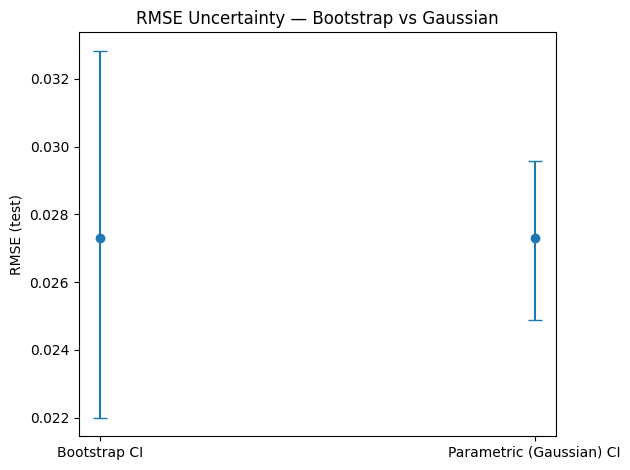

In [5]:
plt.figure()
x = np.arange(2)
point = [base_metrics["rmse_test"], base_metrics["rmse_test"]]
low   = [base_metrics["rmse_test"] - lo_b, base_metrics["rmse_test"] - lo_p]
high  = [hi_b - base_metrics["rmse_test"], hi_p - base_metrics["rmse_test"]]
plt.errorbar(x, point, yerr=[low, high], fmt='o', capsize=5)
plt.xticks(x, ["Bootstrap CI", "Parametric (Gaussian) CI"])
plt.ylabel("RMSE (test)")
plt.title("RMSE Uncertainty — Bootstrap vs Gaussian")
plt.tight_layout()
plt.savefig(OUT_DIR / f"rmse_ci_compare_{stamp()}.png", dpi=150)
plt.show()


Scenario comparison: add polynomial term (still linear in β)

In [6]:
# Add a squared term if available
X_poly = X.copy()
added_term = None
if "mom_21" in X_poly.columns:
    X_poly["mom_21_sq"] = X_poly["mom_21"]**2
    added_term = "mom_21_sq"
elif "rsi_14" in X_poly.columns:
    X_poly["rsi_14_sq"] = X_poly["rsi_14"]**2
    added_term = "rsi_14_sq"

if added_term:
    Xp_train, Xp_test = X_poly.iloc[:split, :], X_poly.iloc[split:, :]
    poly = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
    poly.fit(Xp_train, y_train)
    yhat_te_poly = poly.predict(Xp_test)

    # Metrics
    rmse_base = base_metrics["rmse_test"]
    rmse_poly = rmse(y_test.to_numpy(), yhat_te_poly)
    mae_base  = base_metrics["mae_test"]
    mae_poly  = mean_absolute_error(y_test, yhat_te_poly)
    r2_base   = base_metrics["r2_test"]
    r2_poly   = r2_score(y_test, yhat_te_poly)

    # Bootstrap RMSE CIs for both scenarios
    lo_b0, hi_b0, _ = bootstrap_ci(y_test.to_numpy(), yhat_te,       metric=rmse, n_boot=1000, seed=7)
    lo_b1, hi_b1, _ = bootstrap_ci(y_test.to_numpy(), yhat_te_poly,  metric=rmse, n_boot=1000, seed=7)

    scen_tbl = pd.DataFrame({
        "scenario": ["baseline", f"poly({added_term})"],
        "r2_test":  [r2_base, r2_poly],
        "mae_test": [mae_base, mae_poly],
        "rmse_test":[rmse_base, rmse_poly],
        "rmse_lo":  [lo_b0, lo_b1],
        "rmse_hi":  [hi_b0, hi_b1],
    })
else:
    scen_tbl = pd.DataFrame({"note": ["No candidate column for polynomial term."]})
scen_tbl


,scenario,r2_test,mae_test,rmse_test,rmse_lo,rmse_hi
0,baseline,-0.001190,0.018186,0.027311,0.022211,0.032703
1,poly(mom_21_sq),0.005838,0.018139,0.027215,0.022186,0.032627


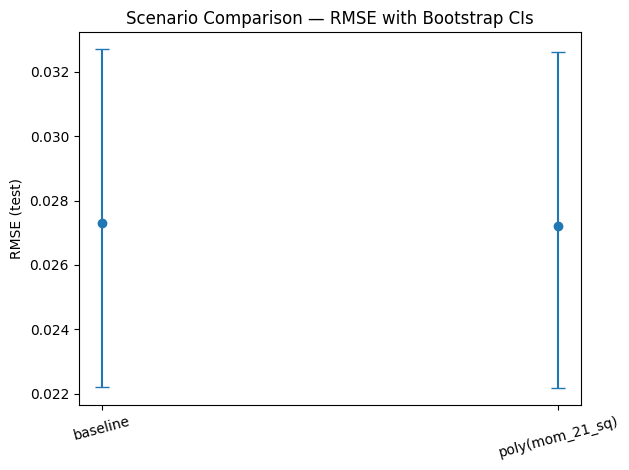

In [7]:
if "scenario" in scen_tbl.columns:
    plt.figure()
    x = np.arange(len(scen_tbl))
    point = scen_tbl["rmse_test"].to_numpy()
    low   = point - scen_tbl["rmse_lo"].to_numpy()
    high  = scen_tbl["rmse_hi"].to_numpy() - point
    plt.errorbar(x, point, yerr=[low, high], fmt='o', capsize=5)
    plt.xticks(x, scen_tbl["scenario"].tolist(), rotation=15)
    plt.ylabel("RMSE (test)")
    plt.title("Scenario Comparison — RMSE with Bootstrap CIs")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"scenario_rmse_{stamp()}.png", dpi=150)
    plt.show()


Subgroup diagnostics (volatility regime)

In [8]:
# Define volatility regime on TEST set using vol_21 (fallback to abs(ret_mean_5) if missing)
if "vol_21" in X.columns:
    vol_series = X.loc[X_test.index, "vol_21"]
else:
    vol_series = X.loc[X_test.index, "ret_mean_5"].abs()

threshold = vol_series.median()
regime = pd.Series(np.where(vol_series > threshold, "high_vol", "low_vol"), index=vol_series.index)

# Residuals for both scenarios (if poly exists)
res_base = pd.Series(y_test.to_numpy() - yhat_te,       index=y_test.index)
if "scenario" in scen_tbl.columns and "poly" in scen_tbl["scenario"].iloc[-1]:
    res_poly = pd.Series(y_test.to_numpy() - yhat_te_poly, index=y_test.index)
else:
    res_poly = None

# Per-regime RMSE
rmse_reg_base = subgroup_metric(y_test, pd.Series(yhat_te, index=y_test.index), regime)
if res_poly is not None:
    rmse_reg_poly = subgroup_metric(y_test, pd.Series(yhat_te_poly, index=y_test.index), regime)

rmse_reg_base, (rmse_reg_poly if res_poly is not None else "no-poly")


(      group    n    metric
 0  high_vol  123  0.025365
 1   low_vol  124  0.029114,
       group    n    metric
 0  high_vol  123  0.025292
 1   low_vol  124  0.028997)

C:\Users\melin\AppData\Local\Temp\ipykernel_23172\3191398638.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=groups)


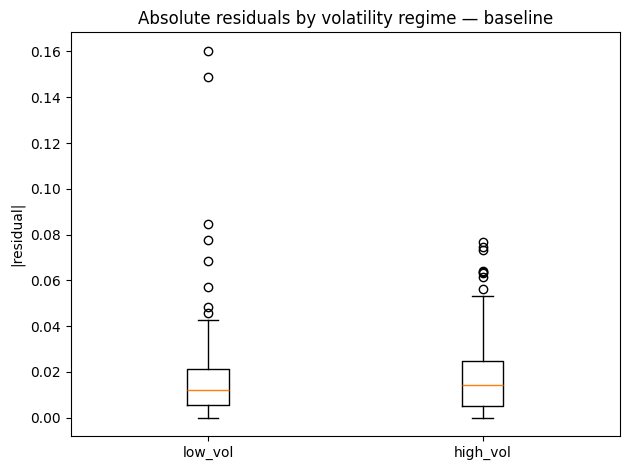

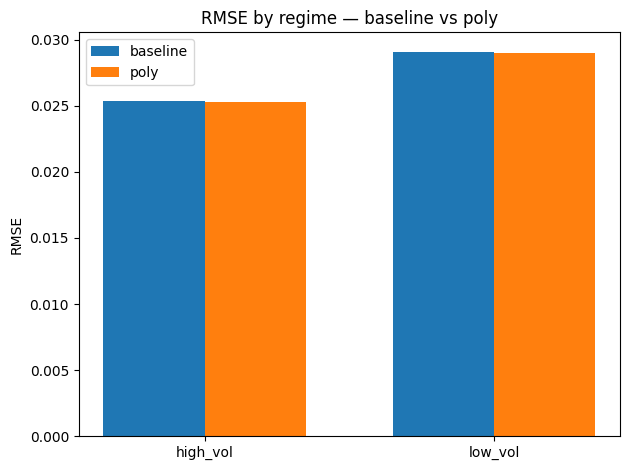

In [9]:
# Boxplot of absolute residuals by regime (baseline)
abs_err = pd.DataFrame({
    "abs_resid": res_base.abs(),
    "regime": regime
}).dropna()

plt.figure()
groups = ["low_vol","high_vol"]
data = [abs_err.loc[abs_err["regime"]==g, "abs_resid"].values for g in groups]
plt.boxplot(data, labels=groups)
plt.title("Absolute residuals by volatility regime — baseline")
plt.ylabel("|residual|")
plt.tight_layout()
plt.savefig(OUT_DIR / f"subgroup_residuals_baseline_{stamp()}.png", dpi=150)
plt.show()

# Bar chart of regime RMSE baseline vs poly if available
if res_poly is not None:
    merged = rmse_reg_base.merge(rmse_reg_poly, on="group", suffixes=("_base","_poly"))
    plt.figure()
    x = np.arange(len(merged))
    w = 0.35
    plt.bar(x - w/2, merged["metric_base"], width=w, label="baseline")
    plt.bar(x + w/2, merged["metric_poly"], width=w, label="poly")
    plt.xticks(x, merged["group"])
    plt.ylabel("RMSE")
    plt.title("RMSE by regime — baseline vs poly")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"subgroup_rmse_compare_{stamp()}.png", dpi=150)
    plt.show()


Prediction vs truth (test) with a Gaussian CI band

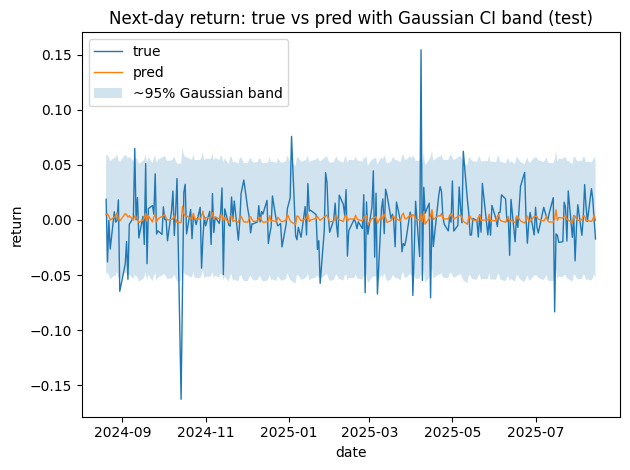

In [10]:
# Gaussian CI band using residual std
sigma = float(np.std(y_test.to_numpy() - yhat_te, ddof=1))
upper = yhat_te + 1.96 * sigma
lower = yhat_te - 1.96 * sigma

plt.figure()
plt.plot(dates_test, y_test.to_numpy(), label="true", linewidth=1)
plt.plot(dates_test, yhat_te, label="pred", linewidth=1)
plt.fill_between(dates_test, lower, upper, alpha=0.2, label="~95% Gaussian band")
plt.title("Next-day return: true vs pred with Gaussian CI band (test)")
plt.xlabel("date"); plt.ylabel("return")
plt.legend(); plt.tight_layout()
plt.savefig(OUT_DIR / f"pred_band_gaussian_{stamp()}.png", dpi=150)
plt.show()


Stakeholder summary

In [11]:
## Stakeholder Summary — Assumptions, Sensitivity, and Risks

**What we evaluated**
- Baseline linear model on engineered features (time-aware split: first 80% train, last 20% test).
- Uncertainty via **bootstrap** and **Gaussian** (parametric) CIs for test RMSE.
- Scenario: **baseline vs polynomial term** (still linear in β).
- Subgroup diagnostics by **volatility regime** (median split of 21-day vol).

**Key findings (example placeholders — replace with your numbers)**
- Test RMSE = X.XXX. Bootstrap 95% CI [L1, H1] vs Gaussian CI [L2, H2] (Gaussian narrower → risk of overconfidence).
- Scenario: Polynomial term changed RMSE by Δ% and R² by Δ; effect was (larger/smaller) in **high-vol** regime.
- Subgroup: High-vol regime had ~Y% higher RMSE; residual boxplots show fatter tails in high-vol.

**Assumptions & sensitivities**
- Bootstrap treats test residuals as i.i.d.; time dependence may widen true uncertainty.
- Model form: adding a squared term reduces curvature in residuals; still linear in coefficients.
- Features use only past information (no leakage).

**Decision framing**
- *Prediction holds if* volatility remains within observed range; performance degrades in high-vol spikes.
- *Model is sensitive to* residual distribution assumptions (Gaussian vs bootstrap) and volatility regime.
- *Next steps:* rolling/expanding validation, regularization (Ridge/Lasso), alternate features (event/calendar), or variance modeling (WLS).


SyntaxError: invalid character '—' (U+2014) (3092686070.py, line 9)